In [1]:
from models.analyzer import FeatureSelectionAnalyzer

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

In [4]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)", 
    "ЧКВ",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "Количество пораженных сосудов(Syntax)",
    "Количество пораженных сосудов(Значимость)",
    "TIMI",
    "Класс ОСН по Killip",
    "ХСН стадия",
    "ФЖ",
    "Пробежки ЖТ",
    "Рецидивирующая ЖТ",
    "Срочность",
    "Экстренная операция(ИБ)(Новый)",
    "Вид операции(ИБ)(Новый)",
    "Тромболизис",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "А-В блокада",
    "А-В блокада (степень)",
]

In [5]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [6]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре',
    'GRACE(Общее)>140',
    'GRACE(Общее)>156',
    'Отек легких(b)',
    'Отек легких(a)', 'Отек легких',
    'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)',
    'МКБ', 'ЖКБ',
    'Протокол коронарографии',
    'Класс ОСН по Killip',
    'ФВ < 40',
    "Мочевина(a)",
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    "TIMI",
    "GRACE(Общее)",
    "GRACE(Общее)>140",
    "GRACE(Общее)>156",
    "TIMI (Летальность)",
    "GRACE (Низкий риск)",
    "GRACE (Средний риск)",
    "GRACE (Высокий риск)",
    "TIMI (Летальность) (Низкий риск)",
    "TIMI (Летальность) (Средний риск)",
    "TIMI (Летальность) (Высокий риск)",
    "Дата и время развития SOFA 8 и более",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Часов в ОРИТ ПОСЛЕ развития SOFA 8",
    "Максимальный прокальцитонин за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки после развития SOFA 8",
    "SOFA первый раз больше или равна 8 баллам",
    "SOFA до развития 8 и более баллов",
    "Используемый антибиотик ДО развития SOFA 8 и более",
    "Левофлоксацин антибиотик ДО развития SOFA 8 и более",
    "Линезолид антибиотик ДО развития SOFA 8 и более",
    "Меропенем антибиотик ДО развития SOFA 8 и более",
    "Метронидазол антибиотик ДО развития SOFA 8 и более",
    "Моксифлоксацин антибиотик ДО развития SOFA 8 и более",
    "Нифуроксазид антибиотик ДО развития SOFA 8 и более",
    "Фосфомицин антибиотик ДО развития SOFA 8 и более",
    "Цефазолин антибиотик ДО развития SOFA 8 и более",
    "Сульбактам антибиотик ДО развития SOFA 8 и более",
    "Цефоперазон антибиотик ДО развития SOFA 8 и более",
    "Цефтриаксон антибиотик ДО развития SOFA 8 и более",
    "Количество часов применения антибиотика ДО развития SOFA 8 и более",
    "Антибиотик после развития SOFA 8 и более",
    "Моксифлоксацин после развития SOFA 8 и более",
    "Левофлоксацин после развития SOFA 8 и более",
    "Азитромицин после развития SOFA 8 и более",
    "Линезолид после развития SOFA 8 и более",
    "Меропенем после развития SOFA 8 и более",
    "Метронидазол после развития SOFA 8 и более",
    "Нифуроксазид после развития SOFA 8 и более",
    "Фосфомицин после развития SOFA 8 и более",
    "Цефазолин после развития SOFA 8 и более",
    "Сульбактам после развития SOFA 8 и более",
    "Цефепим после развития SOFA 8 и более",
    "Цефтриаксон после развития SOFA 8 и более",
    "Через сколько часов после развития SOFA 8 и более был введен антибиотик",
    "APACHE сутки до развития SOFA 8 и более",
    "APACHE сутки ПОСЛЕ развития SOFA 8 и более",
    "АД среднее за сутки до развития SOFA 8",
    "Среднее АД 1 сутки в орит",
    "Среднее АД 3 сутки в орит",
    "Среднее АД 7 сутки в орит",
    "Среднее ЧСС 1 сутки",
    "Среднее ЧСС 3 сутки",
    "Среднее ЧСС 7 сутки",
    "Экстренная операция(ИБ)(Новый)",
    "ИВЛ",
    "Количество дней в реанимации",
    "Часов до введения первого антибиотика",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Apache II",
    "TIMI Летальность",
    "Количество пораженных сосудов Syntax", 
    "Поражение ствола", 
    "Инфаркт-зависимая артерия",
    "Вазопрессорная поддержка",
    "Адреналин",
    "Добутамин",
    "Норадреналин",
    "Левосимендан",
    "Макс АД 1 сут",
    "Мин ЧСС 7 сутки",
    "Макс АД 7 сут",
    "CADILLAC",
    "PAMI",
    "РЕКОРД", 
    "Инфаркт-зависимая артерия Огригированная",
    "СДЛА",
    "killip",
    "повторные операции",
]

In [7]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        print(col, e)

        for i in data.columns:
            if col in i:
                print("Found ", col, i)


GRACE(Общее)>140 "['GRACE(Общее)>140'] not found in axis"
GRACE(Общее)>156 "['GRACE(Общее)>156'] not found in axis"
GRACE (Низкий риск) "['GRACE (Низкий риск)'] not found in axis"
GRACE (Средний риск) "['GRACE (Средний риск)'] not found in axis"
GRACE (Высокий риск) "['GRACE (Высокий риск)'] not found in axis"
TIMI (Летальность) (Низкий риск) "['TIMI (Летальность) (Низкий риск)'] not found in axis"
TIMI (Летальность) (Средний риск) "['TIMI (Летальность) (Средний риск)'] not found in axis"
TIMI (Летальность) (Высокий риск) "['TIMI (Летальность) (Высокий риск)'] not found in axis"
Дата и время развития SOFA 8 и более "['Дата и время развития SOFA 8 и более'] not found in axis"
Используемый антибиотик ДО развития SOFA 8 и более "['Используемый антибиотик ДО развития SOFA 8 и более'] not found in axis"
Левофлоксацин антибиотик ДО развития SOFA 8 и более "['Левофлоксацин антибиотик ДО развития SOFA 8 и более'] not found in axis"
Линезолид антибиотик ДО развития SOFA 8 и более "['Линезолид а

In [19]:
col_names = data.columns 
for col in col_names:
    if "(a)" in col or "(а)" in col:
        data.drop([col], axis=1, inplace=True)
    if " сут" in col or " сутки" in col:
        data.drop([col], axis=1, inplace=True)

In [20]:
data

,Age,Sex,STEMI,ЧКВ,Вид STEMI,Количество пораженных сосудов(Syntax),Количество пораженных сосудов(Значимость),Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,ОНМК (гем) в анамнезе,Стентирование в анамнезе,Тромболизис,Форма ФП,Калий,Дилатация предсердий,ФП b (после чкв),ФП a (в анамнезе),ФП при окс (до чкв),ФП постоянная форма,ФЖ,Пробежки ЖТ,Рецидивирующая ЖТ,MKB,ХСН стадия,ГБ стадия,ГБ риск,АГ,Стенокардия (ИБ),Стенокардия форма(ИБ),Стенокардия ФК (ИБ),СД,ХБП,ЯБ,ФВ ЛЖ (b),ФВ ЛЖ,EDV,МЖП,ЗСЛЖ,ПСПЖ,Размер правого желудочка,Стеноз аортального клапана (степень),Недостаточность аортального клапана (степень),Стеноз митрального клапана (степень),Недостаточность митрального клапана (степень),Недостаточность трикуспидального клапана (степень),НПВ,НПВ диаметр,La1,La2,Ra1,Ra2,Гематокрит,Гемоглобин,Эритроциты,Лейкоциты,Тромбоциты,Нейтрофилы (абсолютное значение),Нейтрофилы (относительное значение),Лимфоциты (абсолютное значение),Лимфоциты (относительное значение),Моноциты (абсолютное значение),Моноциты (относительное значение),Эозинофилы (абсолютное значение),Эозинофилы (относительное значение),Базофилы (абсолютное значение),Базофилы (относительное значение),Сумма всех лейкоцитов,Средний объем эритроцита,Среднее содержание гемоглобина в эритроците,"Ср, концентрация гемоглобина в эритроците",Распределение эритроцитов по объему (RDW-CV),Распределение эритроцитов по объему (RDW-SD),Средний объем тромбоцита (MPV),Расчетная ширина распределения тромбоцитов,Тромбокрит,Коэффициент крупных тромбоцитов,СОЭ,С-реактивный белок,PLR (тромбоциты/лимфоциты абс) (61-239),MLR (моноциты/лимфоциты),LMR (лимфоциты абс/моноциты абс),SII (тромбоциты*нейтрофилы абс / лимфоциты абс),ELR (эозинофилы абс/лимфоциты абс,ELR %,ENR (эозин абс/нейтрофилы абс),BLR (базофилы абс/лимфоциты абс),SIRI (NxM)/L,PIV or AISI (NxMxPLT)/L,GLR (глюкоза мг/дл / лимф абс),FLR (fibr/L abs),RLR (RDW/ lymph abs),MPV/PC (MPV/ PLT),Глюкоза в мг/дл,Фибриноген,Эозинофилы(%)(b),Палочкоядерные нейтрофилы(%)(b),Cегментоядерные нейтрофилы(%)(b),Лимфоциты(%)(b),Моноциты(%)(b),Общий белок(b),Глюкоза(b),АСАТ(b),АЛАТ(b),Билирубин общий(b),Холестерин общий(b),Триглицериды(b),Креатинин(b),Мочевина(b),ЛДГ(b),КФК(b),КФК-МВ(b),ПТИ(b),МНО(b),ТВ(b),АПТВ(b),Продолжительность операции,Вид операции(ИБ)(Новый),Смерть,Тип первой операции БД,Тип повторной операции,интегрилин|эптифибатид|коромакс|агграстат,Рост,Вес,Индекс массы тела,Экстракардиальная артериопатия,Плохая мобильность,Открытая перация на сердце в анамнезе,Срочность,Систолическое АД(b),Диастолического АД(b),ЧСС (b),P,PQ,QRS,QT,RR,Сопутствующие1,Сопутствующие2,Креатинин,СКФ,Тропонин 1 (b),Тропонин 1 > 0.1 (b),Тропонин 1,Тропонин 1 > 0.1,Smoking,Аортальный стеноз (Градиент),Аортальный стеноз (Заключение),ХОБЛ (Новый столбец),Коррекция А-В блокады,Исход А-В блокады,Начало А-В блокады (До/после ЧКВ),А-В блокада,Стенокардия в диагнозе при поступлении,ПИКС в диагнозе при поступлении,Инфаркт-зависимая артерия(Огригированная),Инфаркт-зависимая артерия(Огригированная)2,Ишемический инсульт (Выгрузка из ИБ - временный столбец),Геморрагический инсульт (Выгрузка из ИБ - временный столбец),Инсульт (Выгрузка из ИБ - временный столбец),SpO2,Курит,Медицинская помощь оказана за первые 4 часа,Гипертоническая болезнь,Время ЧКВ,А-В блокаДа (Новый),А-В блокада (степень),Лейкоциты больше 9 до назначения аб,Допмин,Мезатон,Max Aдреналин,Max Добутамин,Max Допмин,Max Норадреналин,Max Мезатона,UA (нестабильная стенокардия),Синдромный диагноз,Натрий (Na) (b),Калий (K) (b),Хлор (Cl) (b),Кальций ионизированный (Ca+) (b),Натрий (Na),Калий (K),Хлор (Cl),Кальций ионизированный (Ca+),pHARTmin (b),pHARTmin,pHARTmax (b),pHARTmax,pO2ARTmin (b),pO2ARTmin,pO2ARTmax (b),pO2ARTmax,pCO2min (b),pCO2min,pCO2max (b),pCO2max,SaO2min (b),SaO2min,SaO2max (b),SaO2max,LACTartMin (b),LACTartMin,LACTartMax (b),LACTartMax,BEArtMin (b),BEArtMin,BEArtMax (b),BEArtMax,HCO3ArtMin (b),HCO3ArtMin,HCO3ArtMax (b),HCO3ArtMax,PHVe

In [22]:
for col in category_cols:
    if col not in cols_to_delete:
        try:
            data[col] = data[col].fillna('missing').astype('str')
            data[col] = data[col].astype('category')
        except Exception:
            pass

In [23]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [24]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [25]:
cat_features = []
for col in X_clean.columns:
    try:
        if X_clean[col].dtype.name == 'category': 
            cat_features.append(col)
    except Exception as e:
        print(col)

In [26]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [27]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [28]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [29]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [30]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='roc_auc')

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/243 [00:25<1:41:51, 25.25s/it, roc_auc=0.7994, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7994


  1%|          | 2/243 [00:54<1:50:28, 27.51s/it, roc_auc=0.8630, Features=2]

Step 2: Добавлен признак 'MKB', roc_auc: 0.8630


...

Step 14: Добавлен признак 'Количество_пораженных_сосудов_Syntax', roc_auc: 0.9602


  6%|▌         | 15/243 [09:56<2:47:33, 44.09s/it, roc_auc=0.9608, Features=15]

Step 15: Добавлен признак 'АГ', roc_auc: 0.9608


  6%|▌         | 15/243 [10:42<2:42:43, 42.82s/it, roc_auc=0.9608, Features=15]

Step 16: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 15


In [31]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/242 [04:08<16:39:16, 248.78s/it, roc_auc=0.9583, Features=242]

Step 1: Удален признак 'Тип_повторной_операции', roc_auc: 0.9583


  1%|          | 2/242 [08:16<16:32:52, 248.22s/it, roc_auc=0.9610, Features=241]

Step 2: Удален признак 'Моноциты_абсолютное_значение', roc_auc: 0.9610


  1%|          | 2/242 [12:22<24:44:31, 371.13s/it, roc_auc=0.9610, Features=241]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 241



=== СРАВНЕНИЕ МЕТОДОВ ===


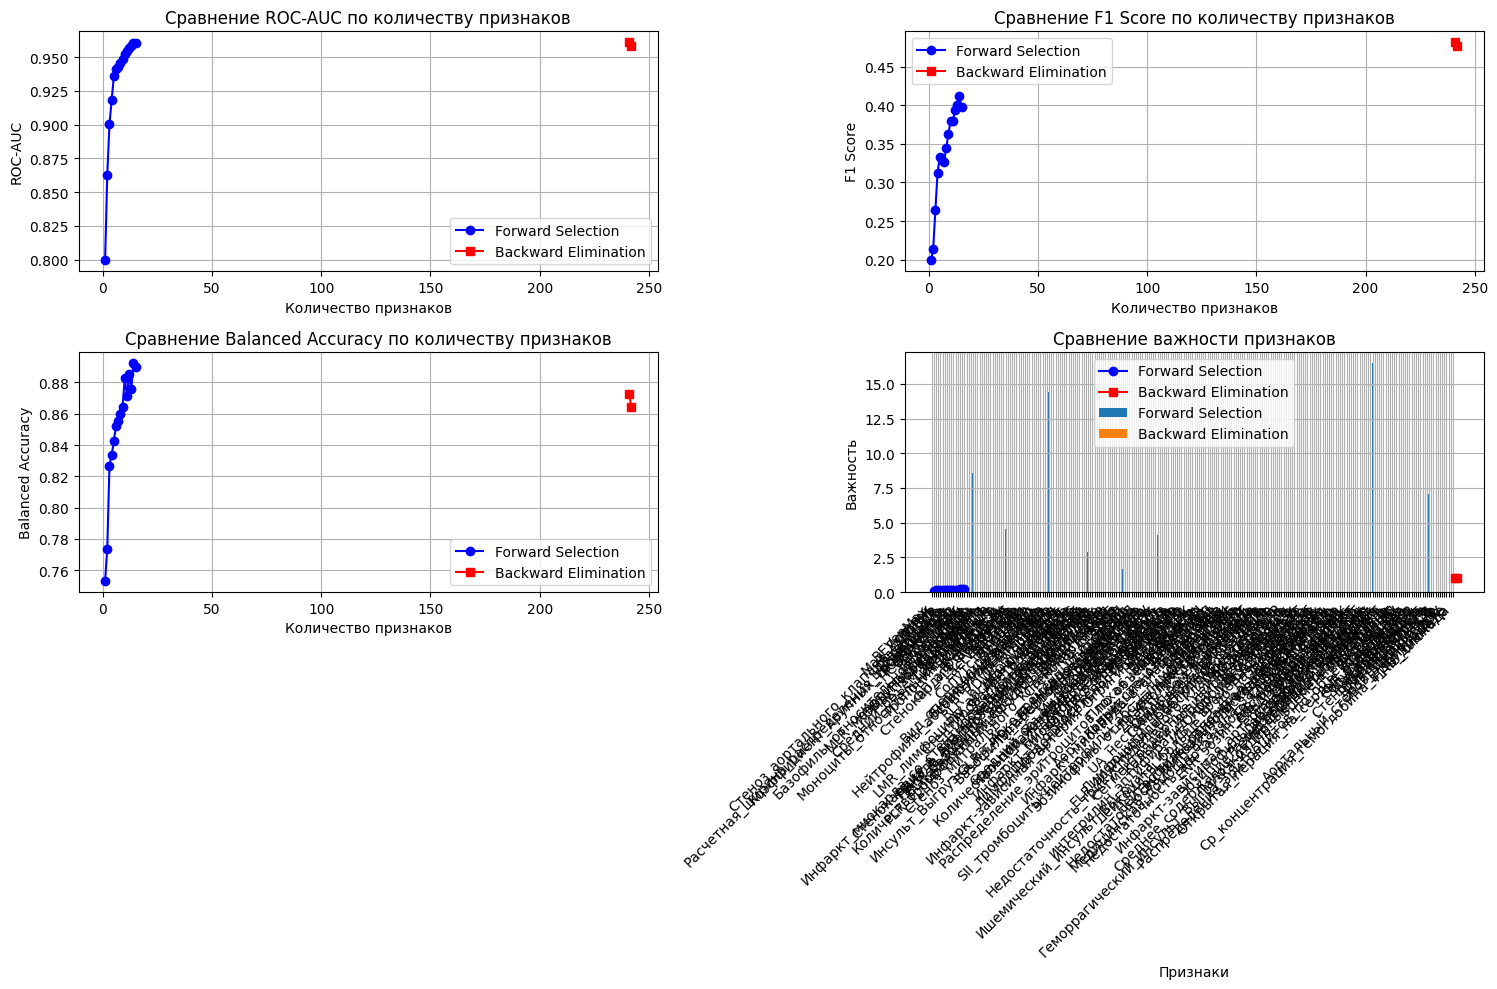

In [32]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [33]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 15 признаков) ===
Лучший Threshold: 0.8600 (F1=0.6091)
По Youden's J: 0.3516


In [34]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 241 признаков) ===
Лучший Threshold: 0.8100 (F1=0.6345)
По Youden's J: 0.2686



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


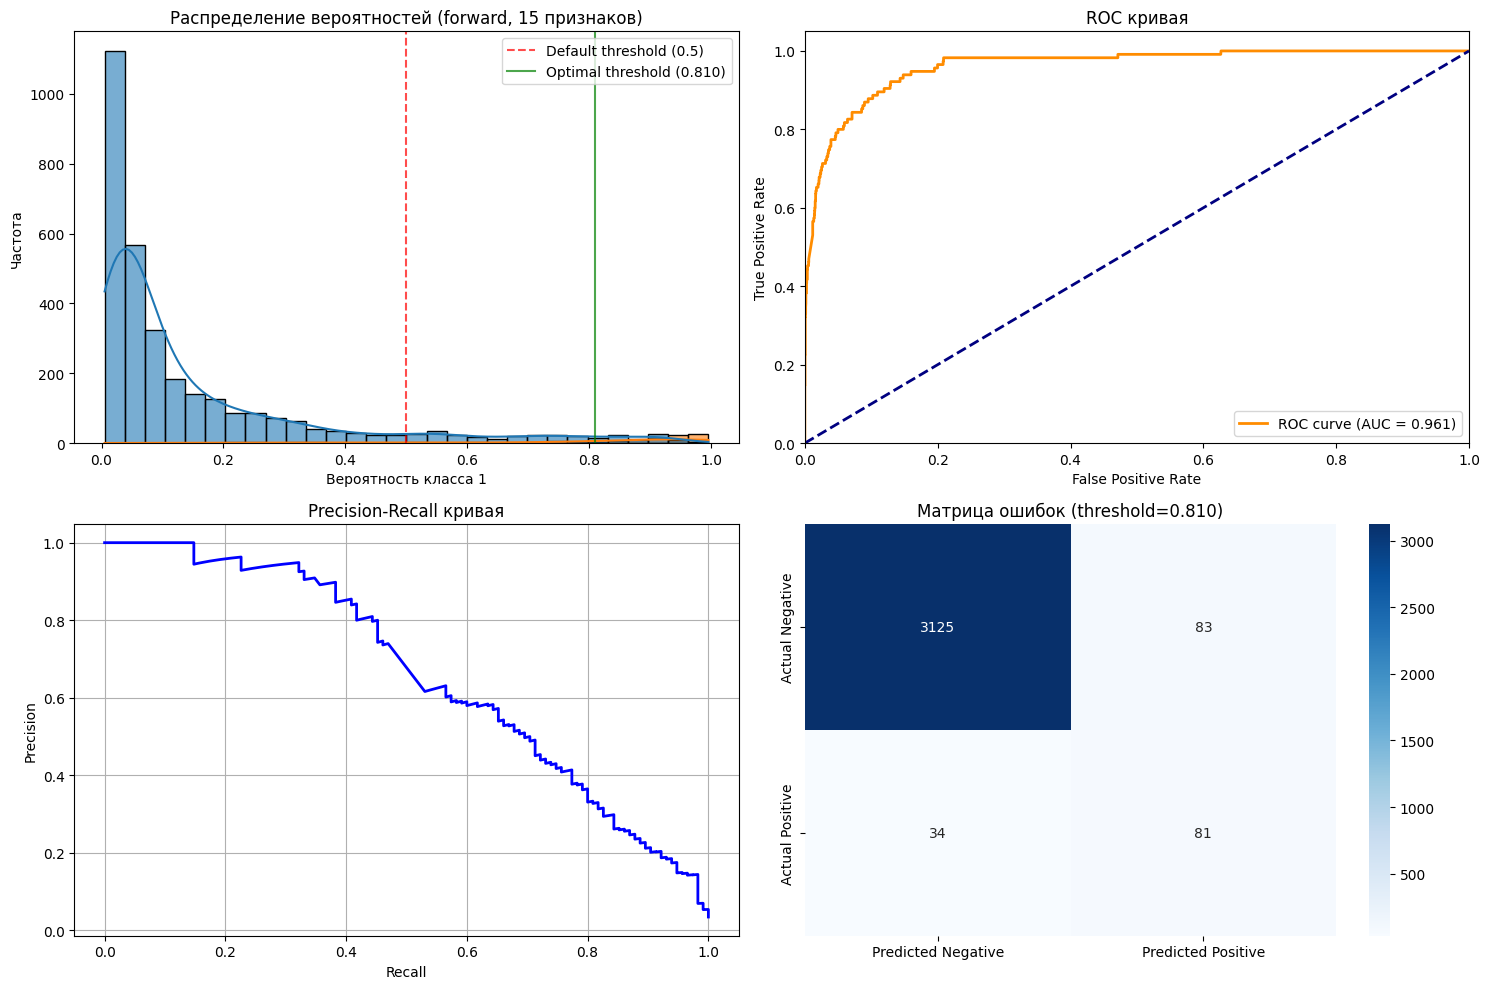

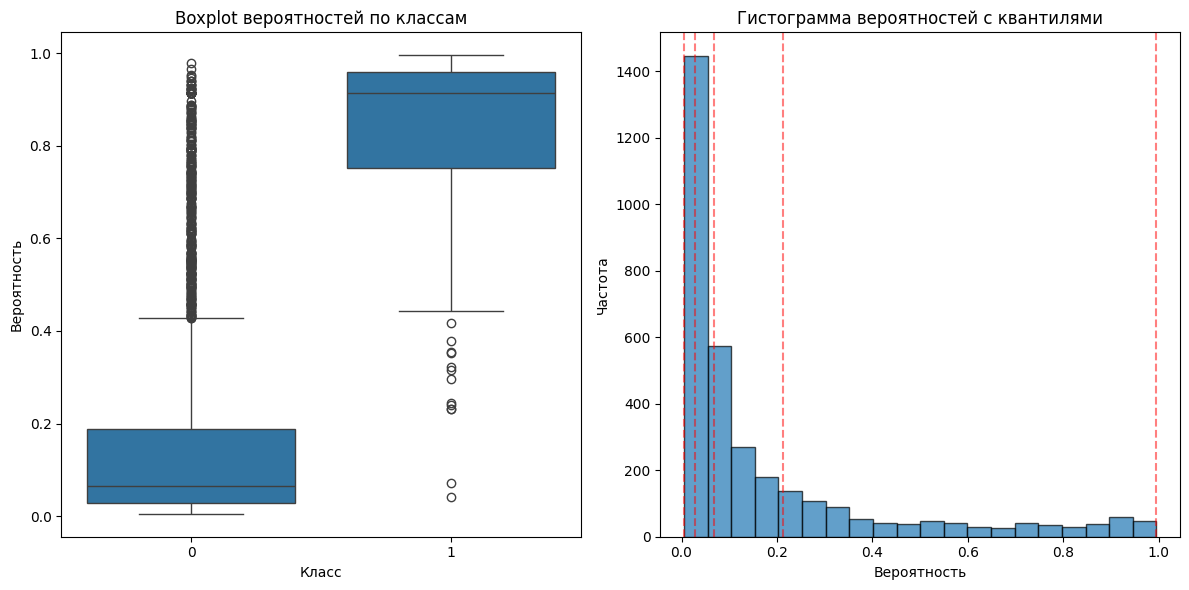

In [35]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


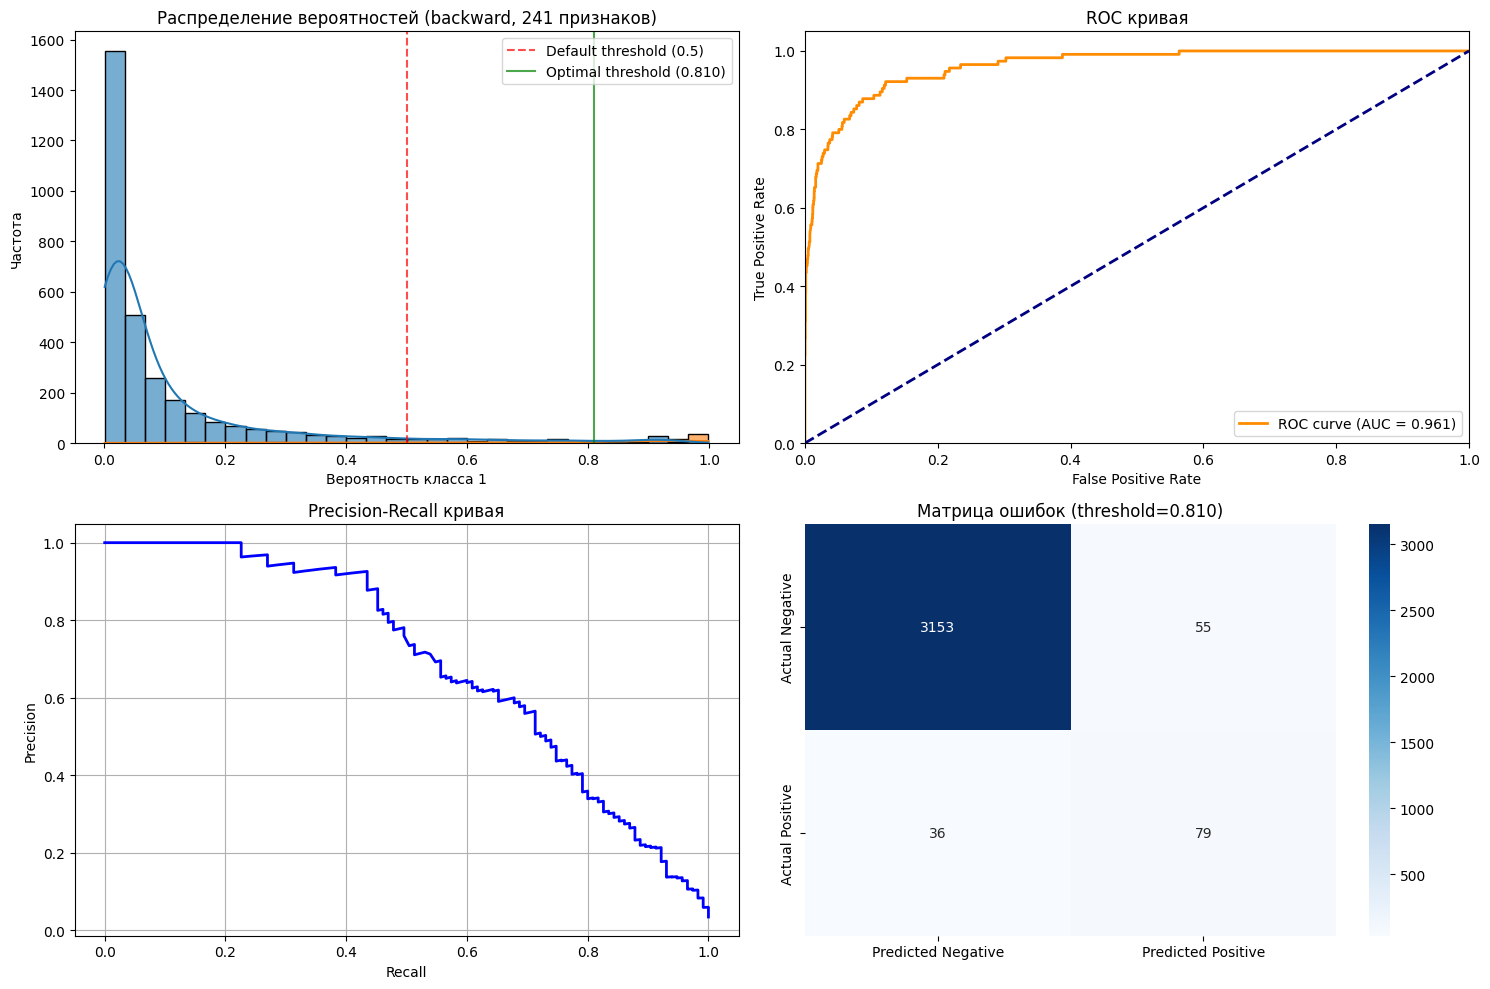

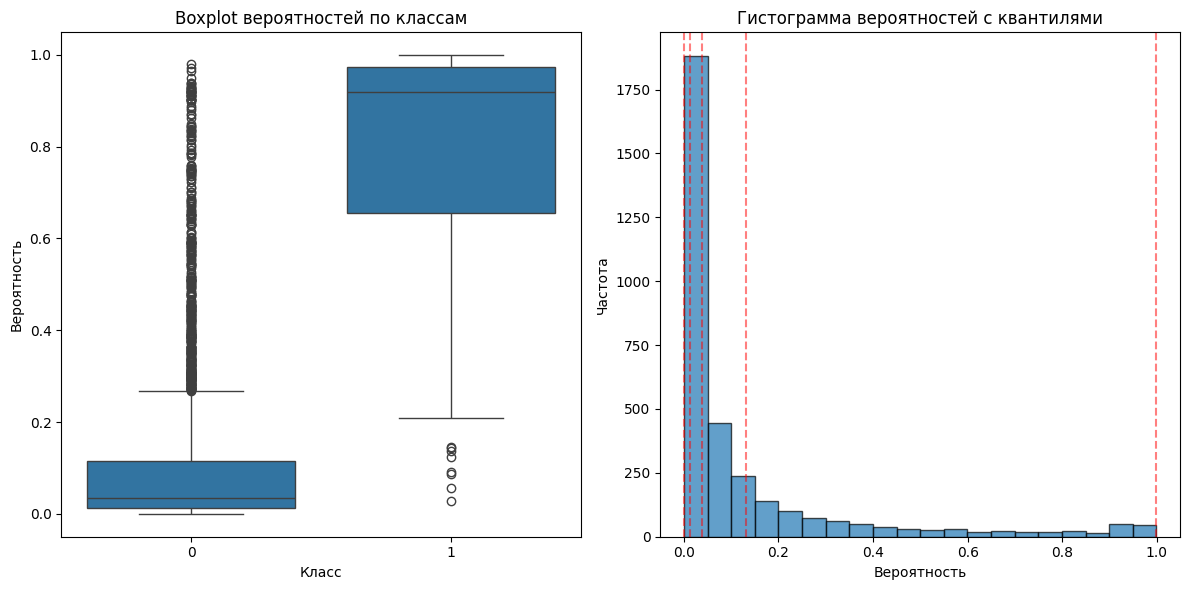

In [36]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [37]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 14
Лучшая f1: 0.4115
Признаки: ['Креатинин', 'MKB', 'Синдромный_диагноз', 'Систолическое_АД_b', 'Аортальный_стеноз_Градиент', 'ФП_при_окс_до_чкв', 'pCO2min', 'SpO2', 'Эозинофилы_абсолютное_значение', 'Вид_операции_ИБ_Новый', 'ЧСС_b', 'ELR_%', 'Стенокардия_в_диагнозе_при_поступлении', 'Количество_пораженных_сосудов_Syntax']

Важность признаков:
  Эозинофилы_абсолютное_значение: 16.4781
  MKB: 14.3856
  Синдромный_диагноз: 9.9308
  Вид_операции_ИБ_Новый: 9.8994
  ЧСС_b: 8.5599
  Креатинин: 7.0562
  Аортальный_стеноз_Градиент: 6.6507
  Систолическое_АД_b: 5.4377
  pCO2min: 5.2087
  ELR_%: 4.5733
  Количество_пораженных_сосудов_Syntax: 4.1137
  ФП_при_окс_до_чкв: 3.1790
  Стенокардия_в_диагнозе_при_поступлении: 2.8984
  SpO2: 1.6284
=== Лучшие признаки (backward) ===
Количество признаков: 241
Лучшая f1: 0.4817
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосуд

In [38]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9602 с 14 признаками
Лучший ROC AUC (Backward): 0.9610 с 241 признаками
Оптимальный порог для бинарной классификации: 0.8100


-----------------

In [39]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [40]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/243 [00:13<55:59, 13.88s/it, roc_auc=0.7900, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7900


  1%|          | 2/243 [00:31<1:03:55, 15.92s/it, roc_auc=0.8499, Features=2]

Step 2: Добавлен признак 'UA_нестабильная_стенокардия', roc_auc: 0.8499


...

Step 12: Добавлен признак 'Тип_повторной_операции', roc_auc: 0.9569


  5%|▌         | 13/243 [04:46<1:35:49, 25.00s/it, roc_auc=0.9571, Features=13]

Step 13: Добавлен признак 'Время_ЧКВ', roc_auc: 0.9571


  5%|▌         | 13/243 [05:12<1:32:03, 24.02s/it, roc_auc=0.9571, Features=13]

Step 14: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 13


In [41]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/242 [03:11<12:47:11, 191.00s/it, roc_auc=0.9589, Features=242]

Step 1: Удален признак 'Аортальный_стеноз_Заключение', roc_auc: 0.9589


  1%|          | 2/242 [06:20<12:40:58, 190.24s/it, roc_auc=0.9591, Features=241]

Step 2: Удален признак 'MLR_моноциты/лимфоциты', roc_auc: 0.9591


...

Step 13: Удален признак 'Max_Добутамин', roc_auc: 0.9605


  6%|▌         | 14/242 [42:07<11:04:02, 174.75s/it, roc_auc=0.9605, Features=229]

Step 14: Удален признак 'МНО_b', roc_auc: 0.9605


  6%|▌         | 14/242 [44:58<12:12:29, 192.76s/it, roc_auc=0.9605, Features=229]

Step 15: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 229


In [43]:
1

1


=== СРАВНЕНИЕ МЕТОДОВ ===


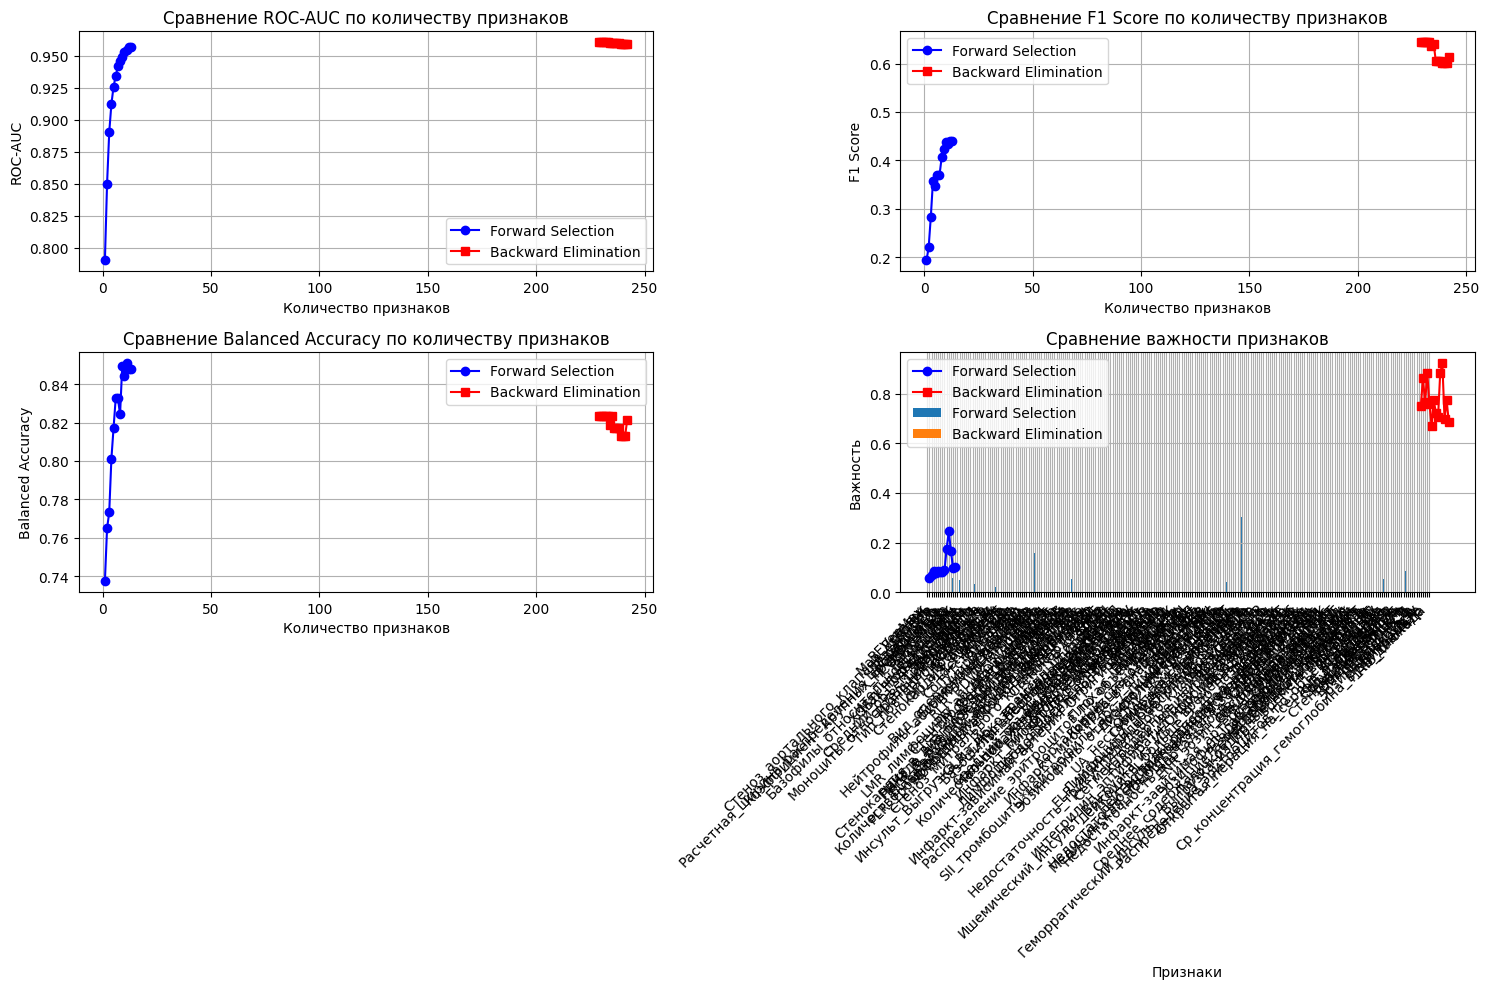

In [44]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [45]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 13 признаков) ===
Лучший Threshold: 0.8600 (F1=0.5680)
По Youden's J: 0.1773


In [46]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 229 признаков) ===
Лучший Threshold: 0.5000 (F1=0.6441)
По Youden's J: 0.1144



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


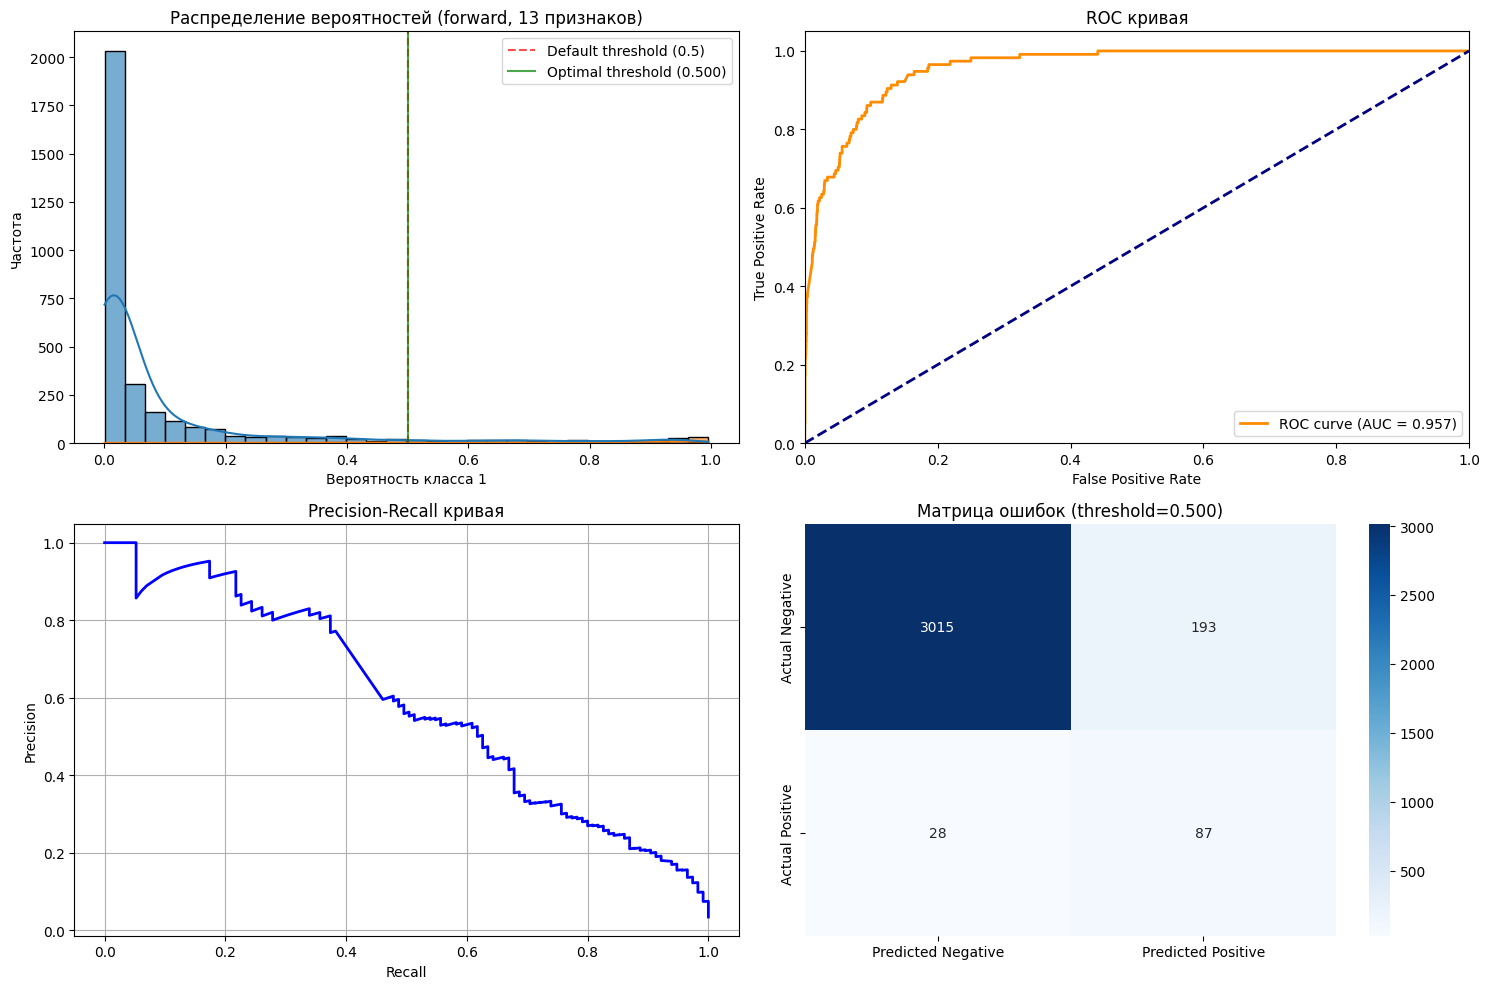

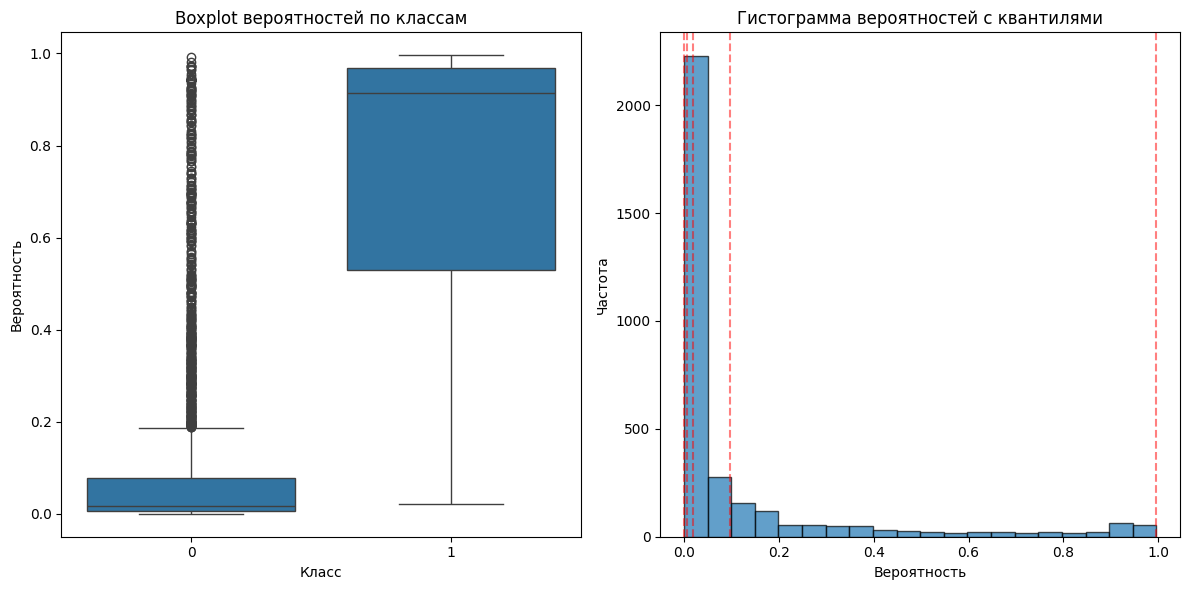

In [47]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


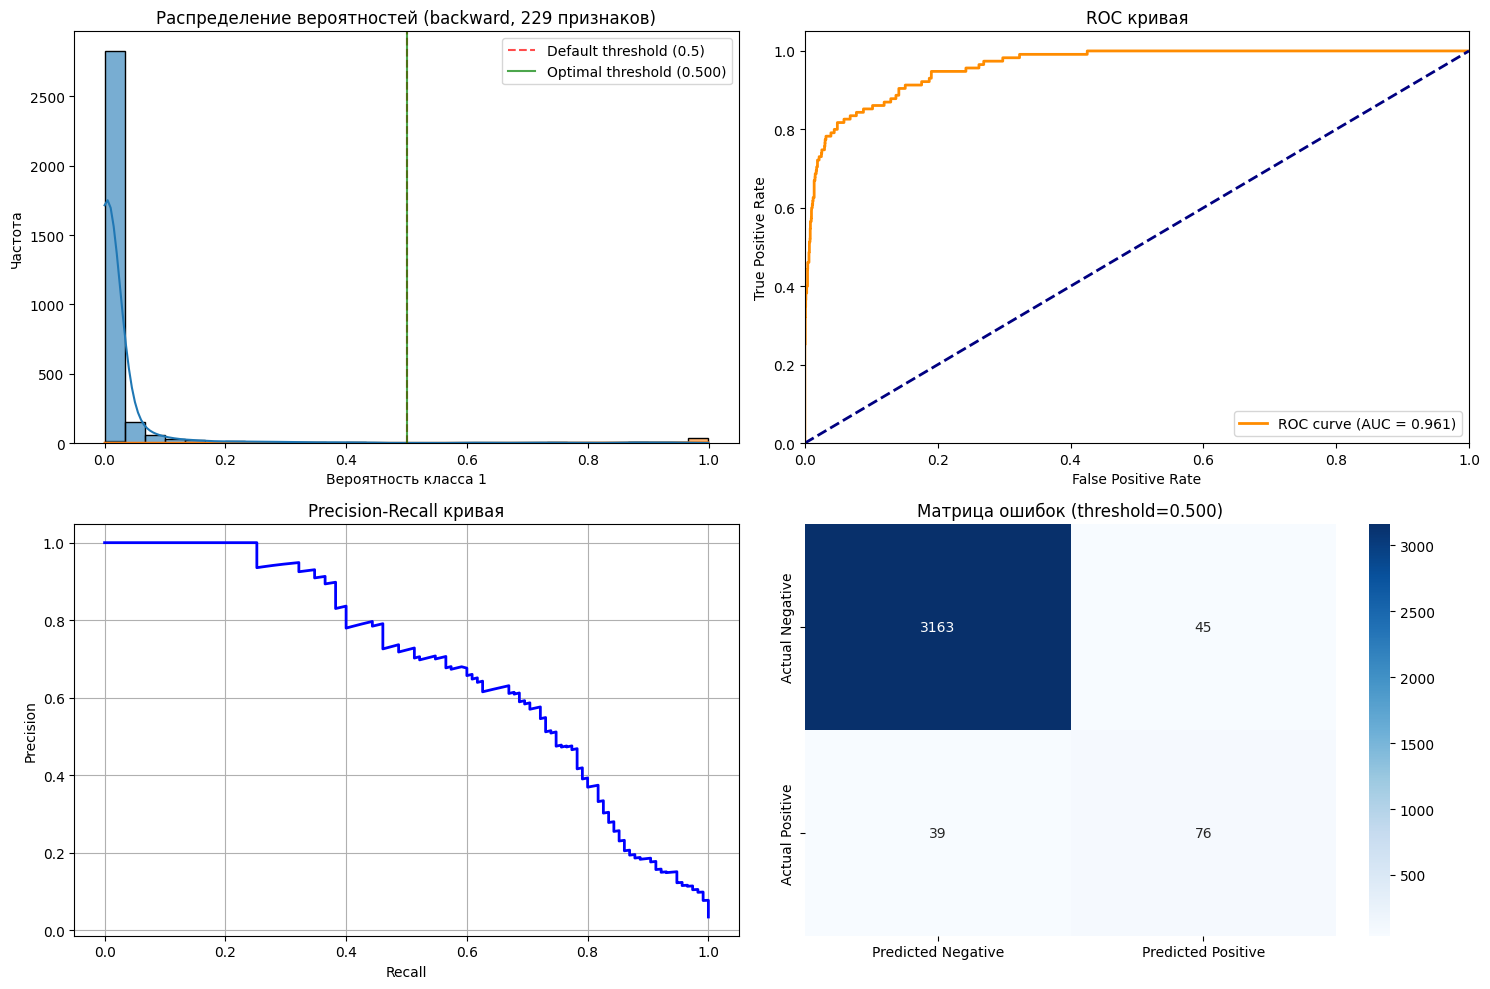

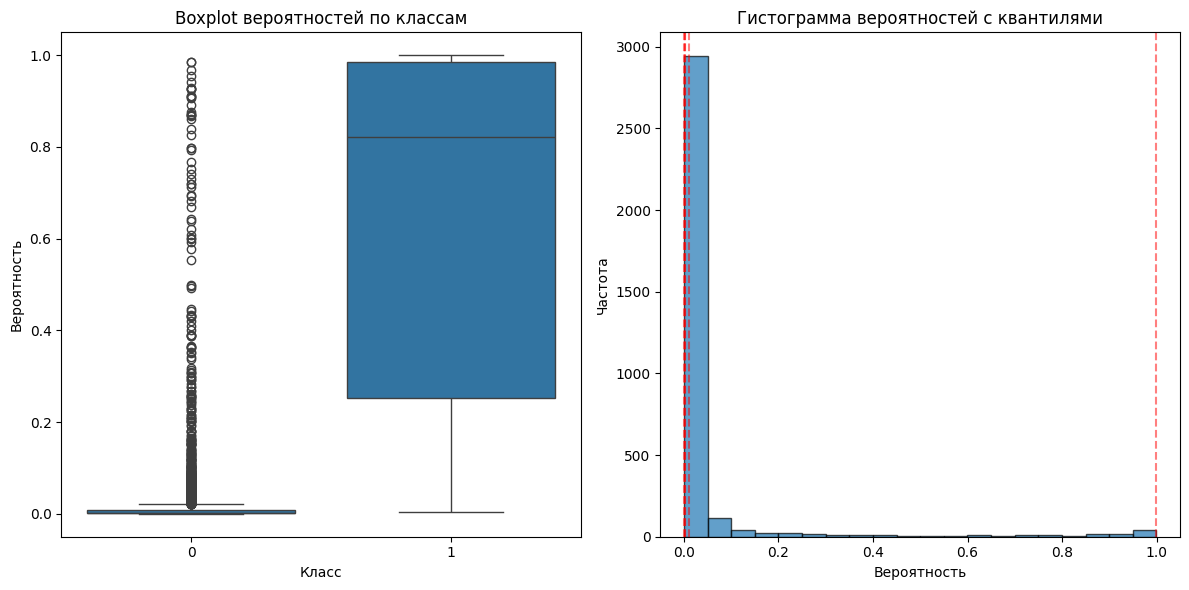

In [48]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [49]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 12
Лучшая f1: 0.4405
Признаки: ['Креатинин', 'UA_нестабильная_стенокардия', 'Нейтрофилы_абсолютное_значение', 'La2', 'SaO2max_b', 'Диастолического_АД_b', 'Гемоглобин', 'Срочность', 'Стенокардия_в_диагнозе_при_поступлении', 'Натрий_Na', 'pHARTmax_b', 'Тип_повторной_операции']

Важность признаков:
  UA_нестабильная_стенокардия: 0.3016
  Нейтрофилы_абсолютное_значение: 0.1579
  Срочность: 0.1126
  Креатинин: 0.0868
  La2: 0.0575
  Стенокардия_в_диагнозе_при_поступлении: 0.0541
  Натрий_Na: 0.0538
  Гемоглобин: 0.0479
  Диастолического_АД_b: 0.0406
  pHARTmax_b: 0.0342
  SaO2max_b: 0.0328
  Тип_повторной_операции: 0.0202
=== Лучшие признаки (backward) ===
Количество признаков: 233
Лучшая f1: 0.6441
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_ан

In [50]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9569 с 12 признаками
Лучший ROC AUC (Backward): 0.9605 с 233 признаками
Оптимальный порог для бинарной классификации: 0.5000


In [51]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [52]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/243 [00:12<49:40, 12.32s/it, roc_auc=0.7759, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7759


  1%|          | 2/243 [00:30<1:03:34, 15.83s/it, roc_auc=0.8464, Features=2]

Step 2: Добавлен признак 'UA_нестабильная_стенокардия', roc_auc: 0.8464


...

Step 11: Добавлен признак 'Стенокардия_форма_ИБ', roc_auc: 0.9577


  5%|▍         | 12/243 [04:17<1:30:53, 23.61s/it, roc_auc=0.9586, Features=12]

Step 12: Добавлен признак 'Плохая_мобильность', roc_auc: 0.9586


  5%|▍         | 12/243 [04:41<1:30:22, 23.47s/it, roc_auc=0.9586, Features=12]

Step 13: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 12


In [53]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== BACKWARD SELECTION ===
Запуск Backward Elimination...


  0%|          | 1/242 [01:51<7:28:54, 111.76s/it, roc_auc=0.9670, Features=242]

Step 1: Удален признак 'Max_Норадреналин', roc_auc: 0.9670


  1%|          | 2/242 [03:43<7:26:19, 111.58s/it, roc_auc=0.9684, Features=241]

Step 2: Удален признак 'pCO2min', roc_auc: 0.9684


...

Step 9: Удален признак 'Палочкоядерные_нейтрофилы_%_b', roc_auc: 0.9702


  4%|▍         | 10/242 [18:08<6:52:14, 106.61s/it, roc_auc=0.9702, Features=233]

Step 10: Удален признак 'BNP', roc_auc: 0.9702


  4%|▍         | 10/242 [19:53<7:41:25, 119.33s/it, roc_auc=0.9702, Features=233]

Step 11: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 233



=== СРАВНЕНИЕ МЕТОДОВ ===


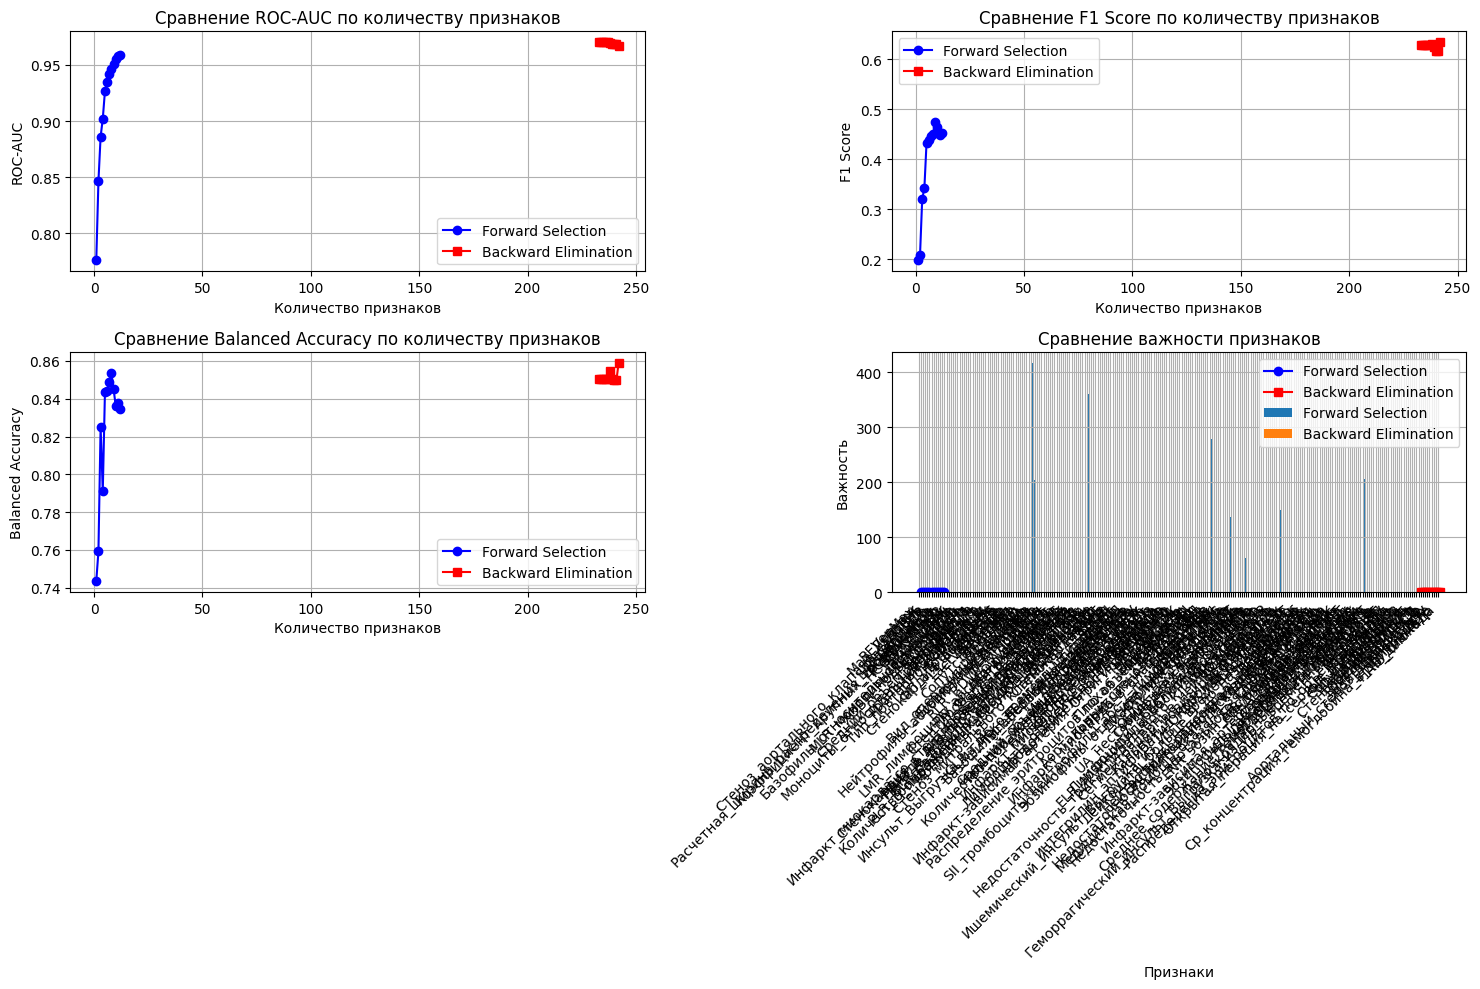

In [54]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [55]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 12 признаков) ===
Лучший Threshold: 0.8100 (F1=0.5975)
По Youden's J: 0.2243


In [56]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 233 признаков) ===
Лучший Threshold: 0.7300 (F1=0.6667)
По Youden's J: 0.0766



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


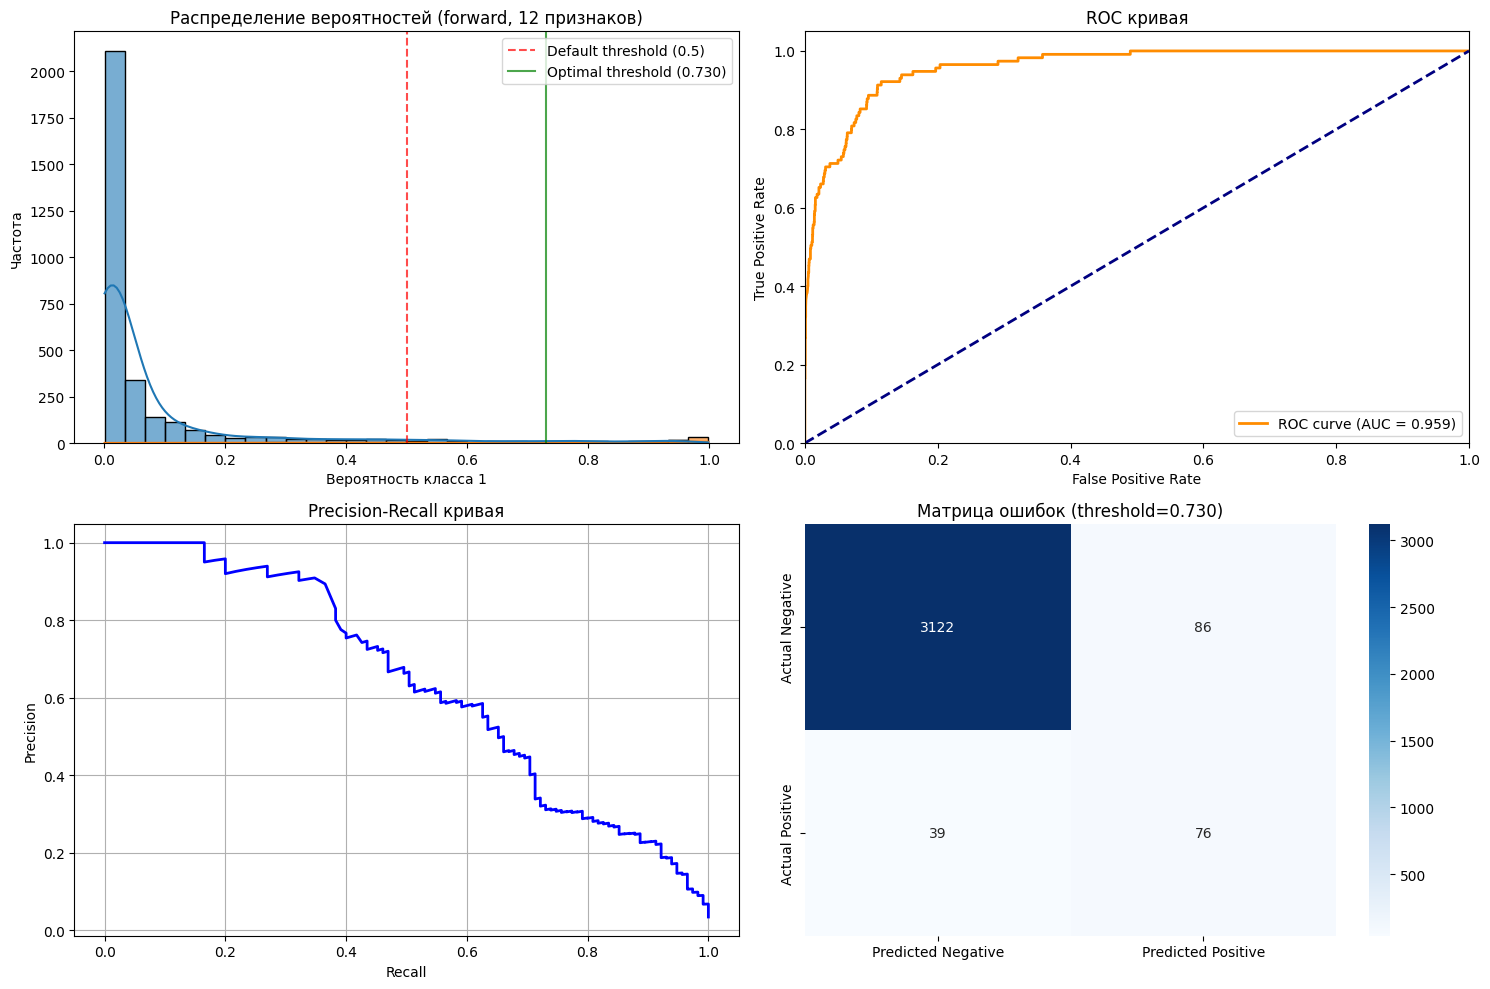

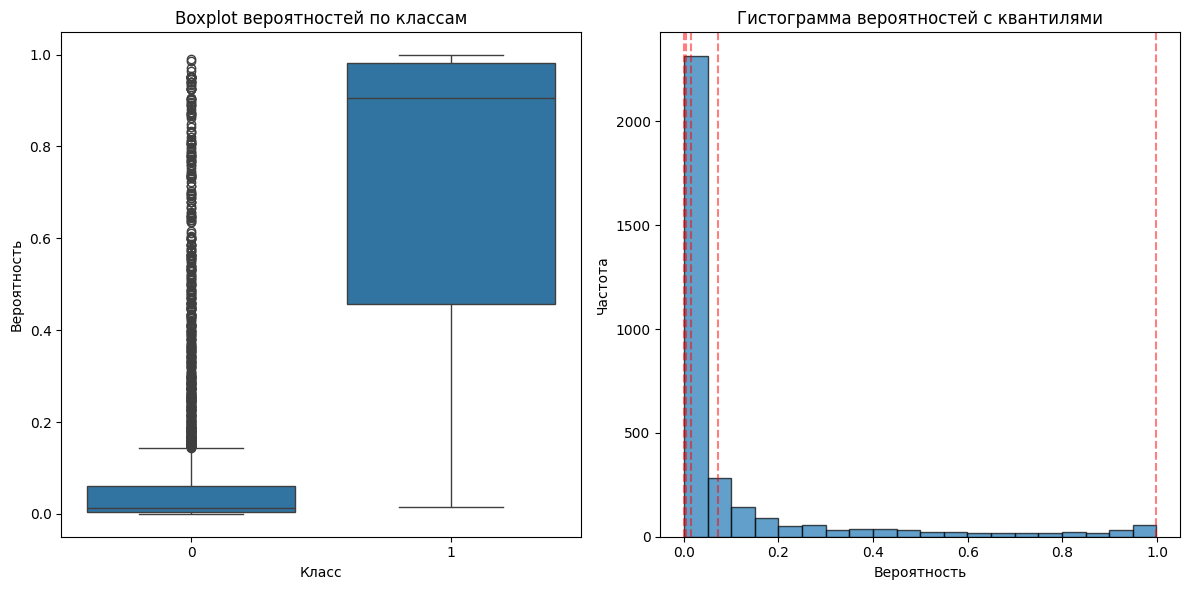

In [57]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


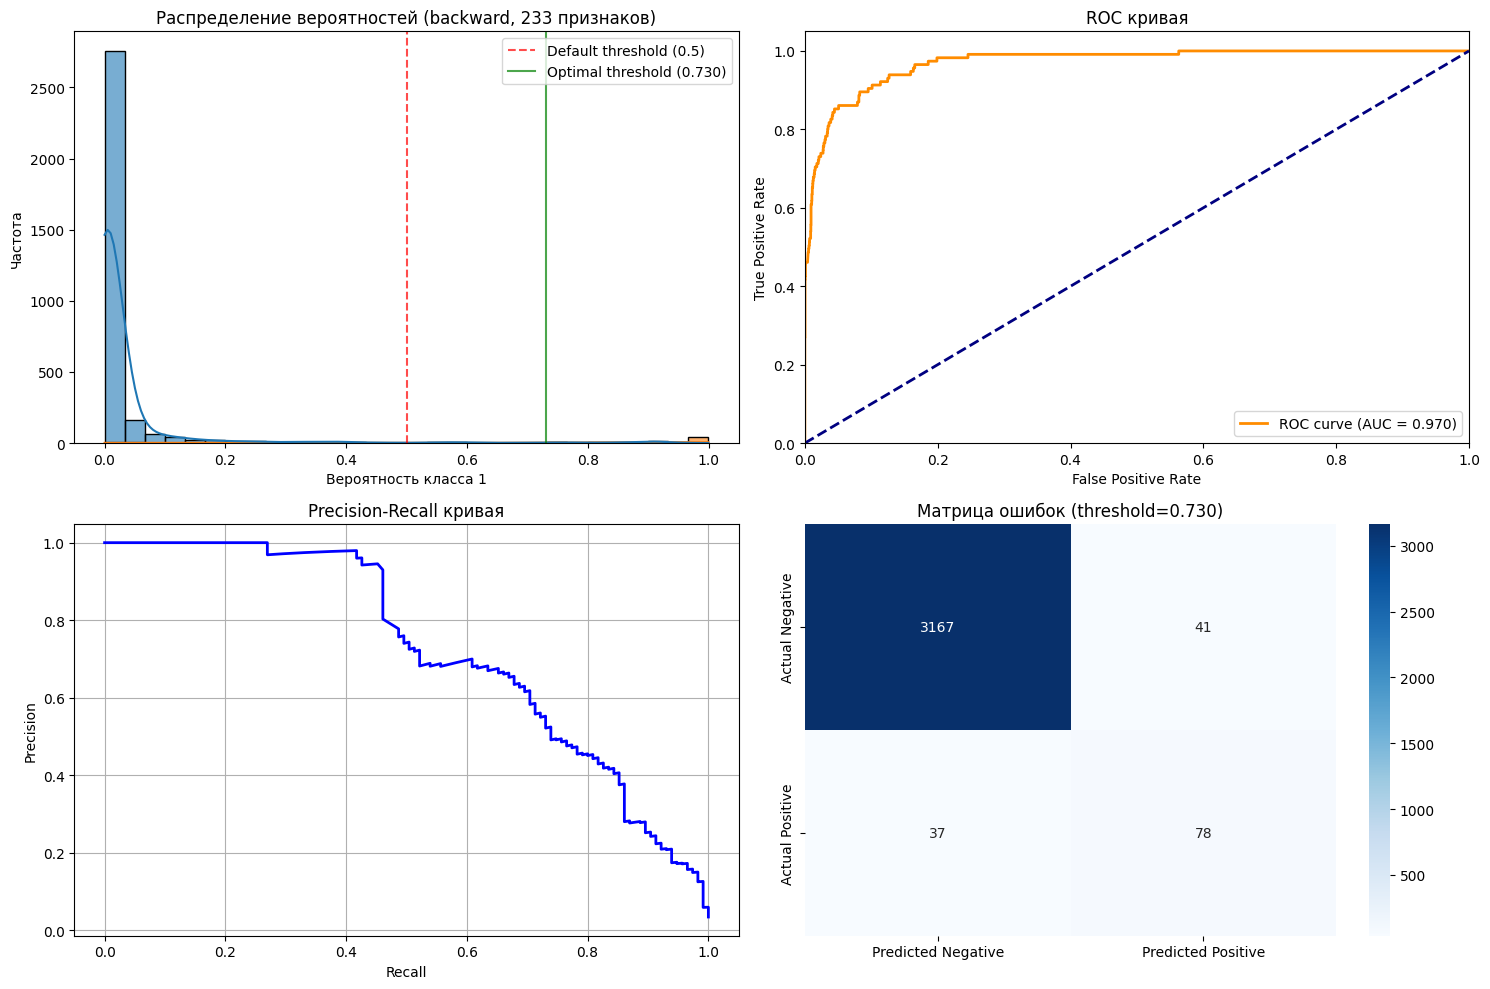

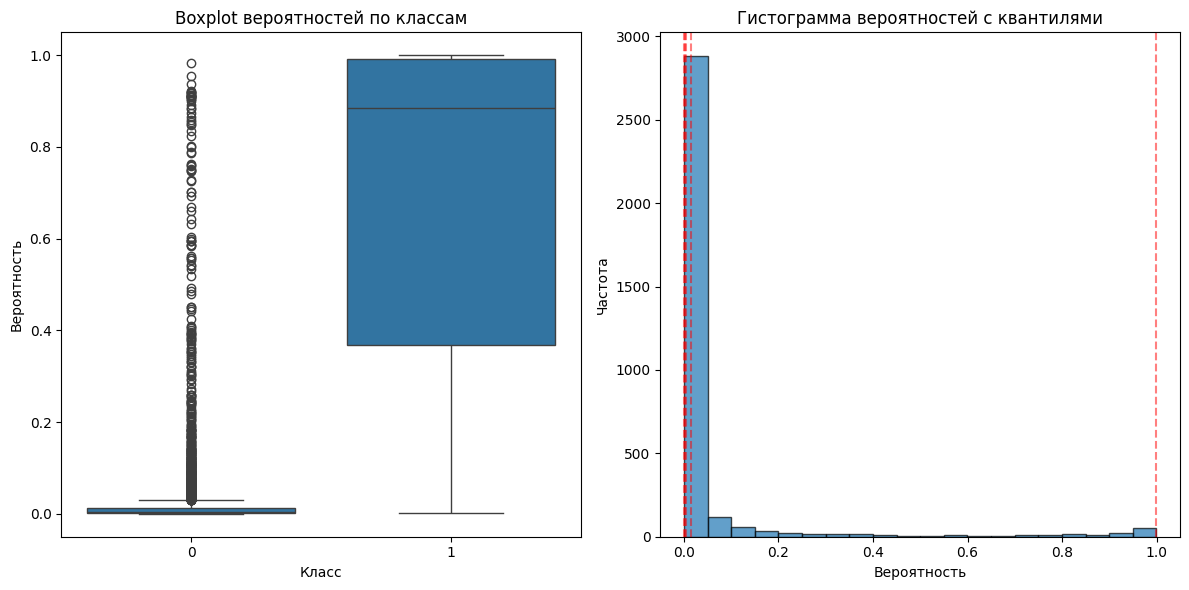

In [58]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [59]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 9
Лучшая f1: 0.4749
Признаки: ['Креатинин', 'UA_нестабильная_стенокардия', 'Размер_правого_желудочка', 'Нейтрофилы_абсолютное_значение', 'MKB', 'Диастолического_АД_b', 'SaO2min_b', 'Age', 'PLR_тромбоциты/лимфоциты_абс_61-239']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 416.0000
  Креатинин: 395.0000
  PLR_тромбоциты/лимфоциты_абс_61-239: 361.0000
  Age: 279.0000
  Размер_правого_желудочка: 206.0000
  MKB: 204.0000
  SaO2min_b: 150.0000
  Диастолического_АД_b: 137.0000
  UA_нестабильная_стенокардия: 62.0000
=== Лучшие признаки (backward) ===
Количество признаков: 242
Лучшая f1: 0.6343
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анам

In [60]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9512 с 9 признаками
Лучший ROC AUC (Backward): 0.9670 с 242 признаками
Оптимальный порог для бинарной классификации: 0.7300
